In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
auction_verification = fetch_ucirepo(id=713)

# data (as pandas dataframes)
X = auction_verification.data.features
y = auction_verification.data.targets

df = X.copy().join(y.copy())

df.head()

,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.result,verification.time
0,0,0,2,1,59,1,0,False,163.316667
1,0,0,2,1,59,2,0,False,200.860000
2,0,0,2,1,59,4,0,False,154.888889
3,0,0,2,1,59,6,0,False,108.640000
4,0,0,2,1,60,1,0,True,85.466667


In [10]:
df.describe()

,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.time
count,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000,2043.000000
mean,1.000000,2.093979,1.883994,0.587861,71.473324,3.252080,0.455213,7336.944574
std,0.816696,0.811269,0.320310,0.492340,8.048740,1.804225,1.062828,10375.393650
min,0.000000,0.000000,1.000000,0.000000,59.000000,1.000000,0.000000,77.916667
25%,0.000000,1.000000,2.000000,0.000000,65.000000,2.000000,0.000000,546.818910
50%,1.000000,2.000000,2.000000,1.000000,70.000000,3.000000,0.000000,1316.983333
75%,2.000000,3.000000,2.000000,1.000000,78.000000,5.000000,0.000000,10876.638889
max,2.000000,3.000000,2.000000,1.000000,90.000000,6.000000,4.000000,44130.520833


In [3]:
# Импорт библиотек
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Предположим, у тебя уже есть DataFrame df
# Логистическая регрессия: предсказываем verification.result

# 1. Признаки и целевая переменная
X_log = df.drop(columns=['verification.result', 'verification.time'])  # убираем цели
y_log = df['verification.result']  # Бинарная цель

# 2. Разделение на обучающую и тестовую выборки
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

# 3. Стандартизация признаков
scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_test_log_scaled = scaler_log.transform(X_test_log)

# 4. Обучение логистической регрессии
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_log_scaled, y_train_log)

# 5. Предсказания и метрики
y_pred_log = log_model.predict(X_test_log_scaled)

print(f'Accuracy: {accuracy_score(y_test_log, y_pred_log):.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test_log, y_pred_log))
print('\nClassification Report:')
print(classification_report(y_test_log, y_pred_log))

Accuracy: 0.8655

Confusion Matrix:
[[351   3]
 [ 52   3]]

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.99      0.93       354
        True       0.50      0.05      0.10        55

    accuracy                           0.87       409
   macro avg       0.69      0.52      0.51       409
weighted avg       0.82      0.87      0.82       409



In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Признаки и цель для регрессии
X_lin = df.drop(columns=['verification.result', 'verification.time'])  # признаки
y_lin = df['verification.time']  # Непрерывная цель

# 2. Разделение
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

# 3. Стандартизация
scaler_lin = StandardScaler()
X_train_lin_scaled = scaler_lin.fit_transform(X_train_lin)
X_test_lin_scaled = scaler_lin.transform(X_test_lin)

# 4. Обучение модели линейной регрессии
lin_model = LinearRegression()
lin_model.fit(X_train_lin_scaled, y_train_lin)

# 5. Предсказания и оценка качества
y_pred_lin = lin_model.predict(X_test_lin_scaled)

mae = mean_absolute_error(y_test_lin, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test_lin, y_pred_lin))
mape = np.mean(np.abs((y_test_lin - y_pred_lin) / y_test_lin)) * 100
r2 = r2_score(y_test_lin, y_pred_lin)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'R^2 Score: {r2:.4f}')

Mean Absolute Error (MAE): 6287.3877
Root Mean Squared Error (RMSE): 8128.7947
Mean Absolute Percentage Error (MAPE): 742.05%
R^2 Score: 0.3664


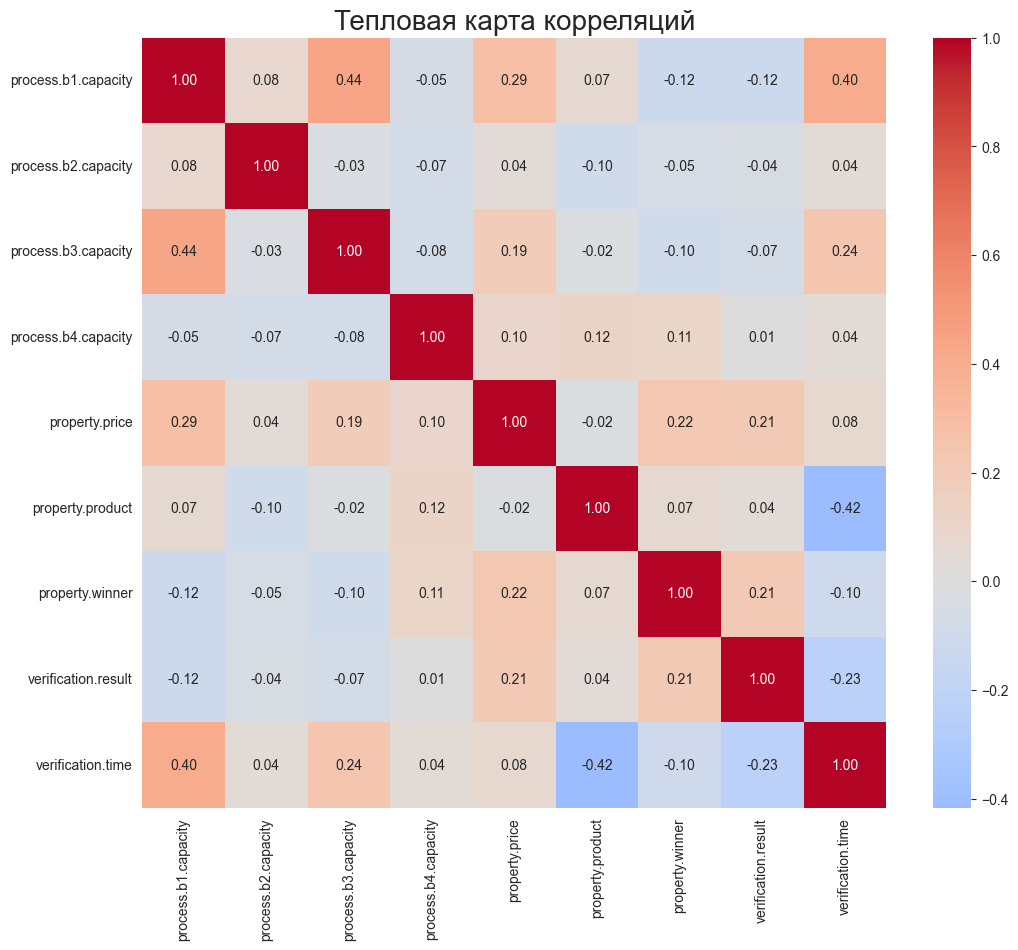

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Вычисляем корреляцию
corr = df.corr()

# Строим тепловую карту
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Тепловая карта корреляций', fontsize=20)
plt.show()

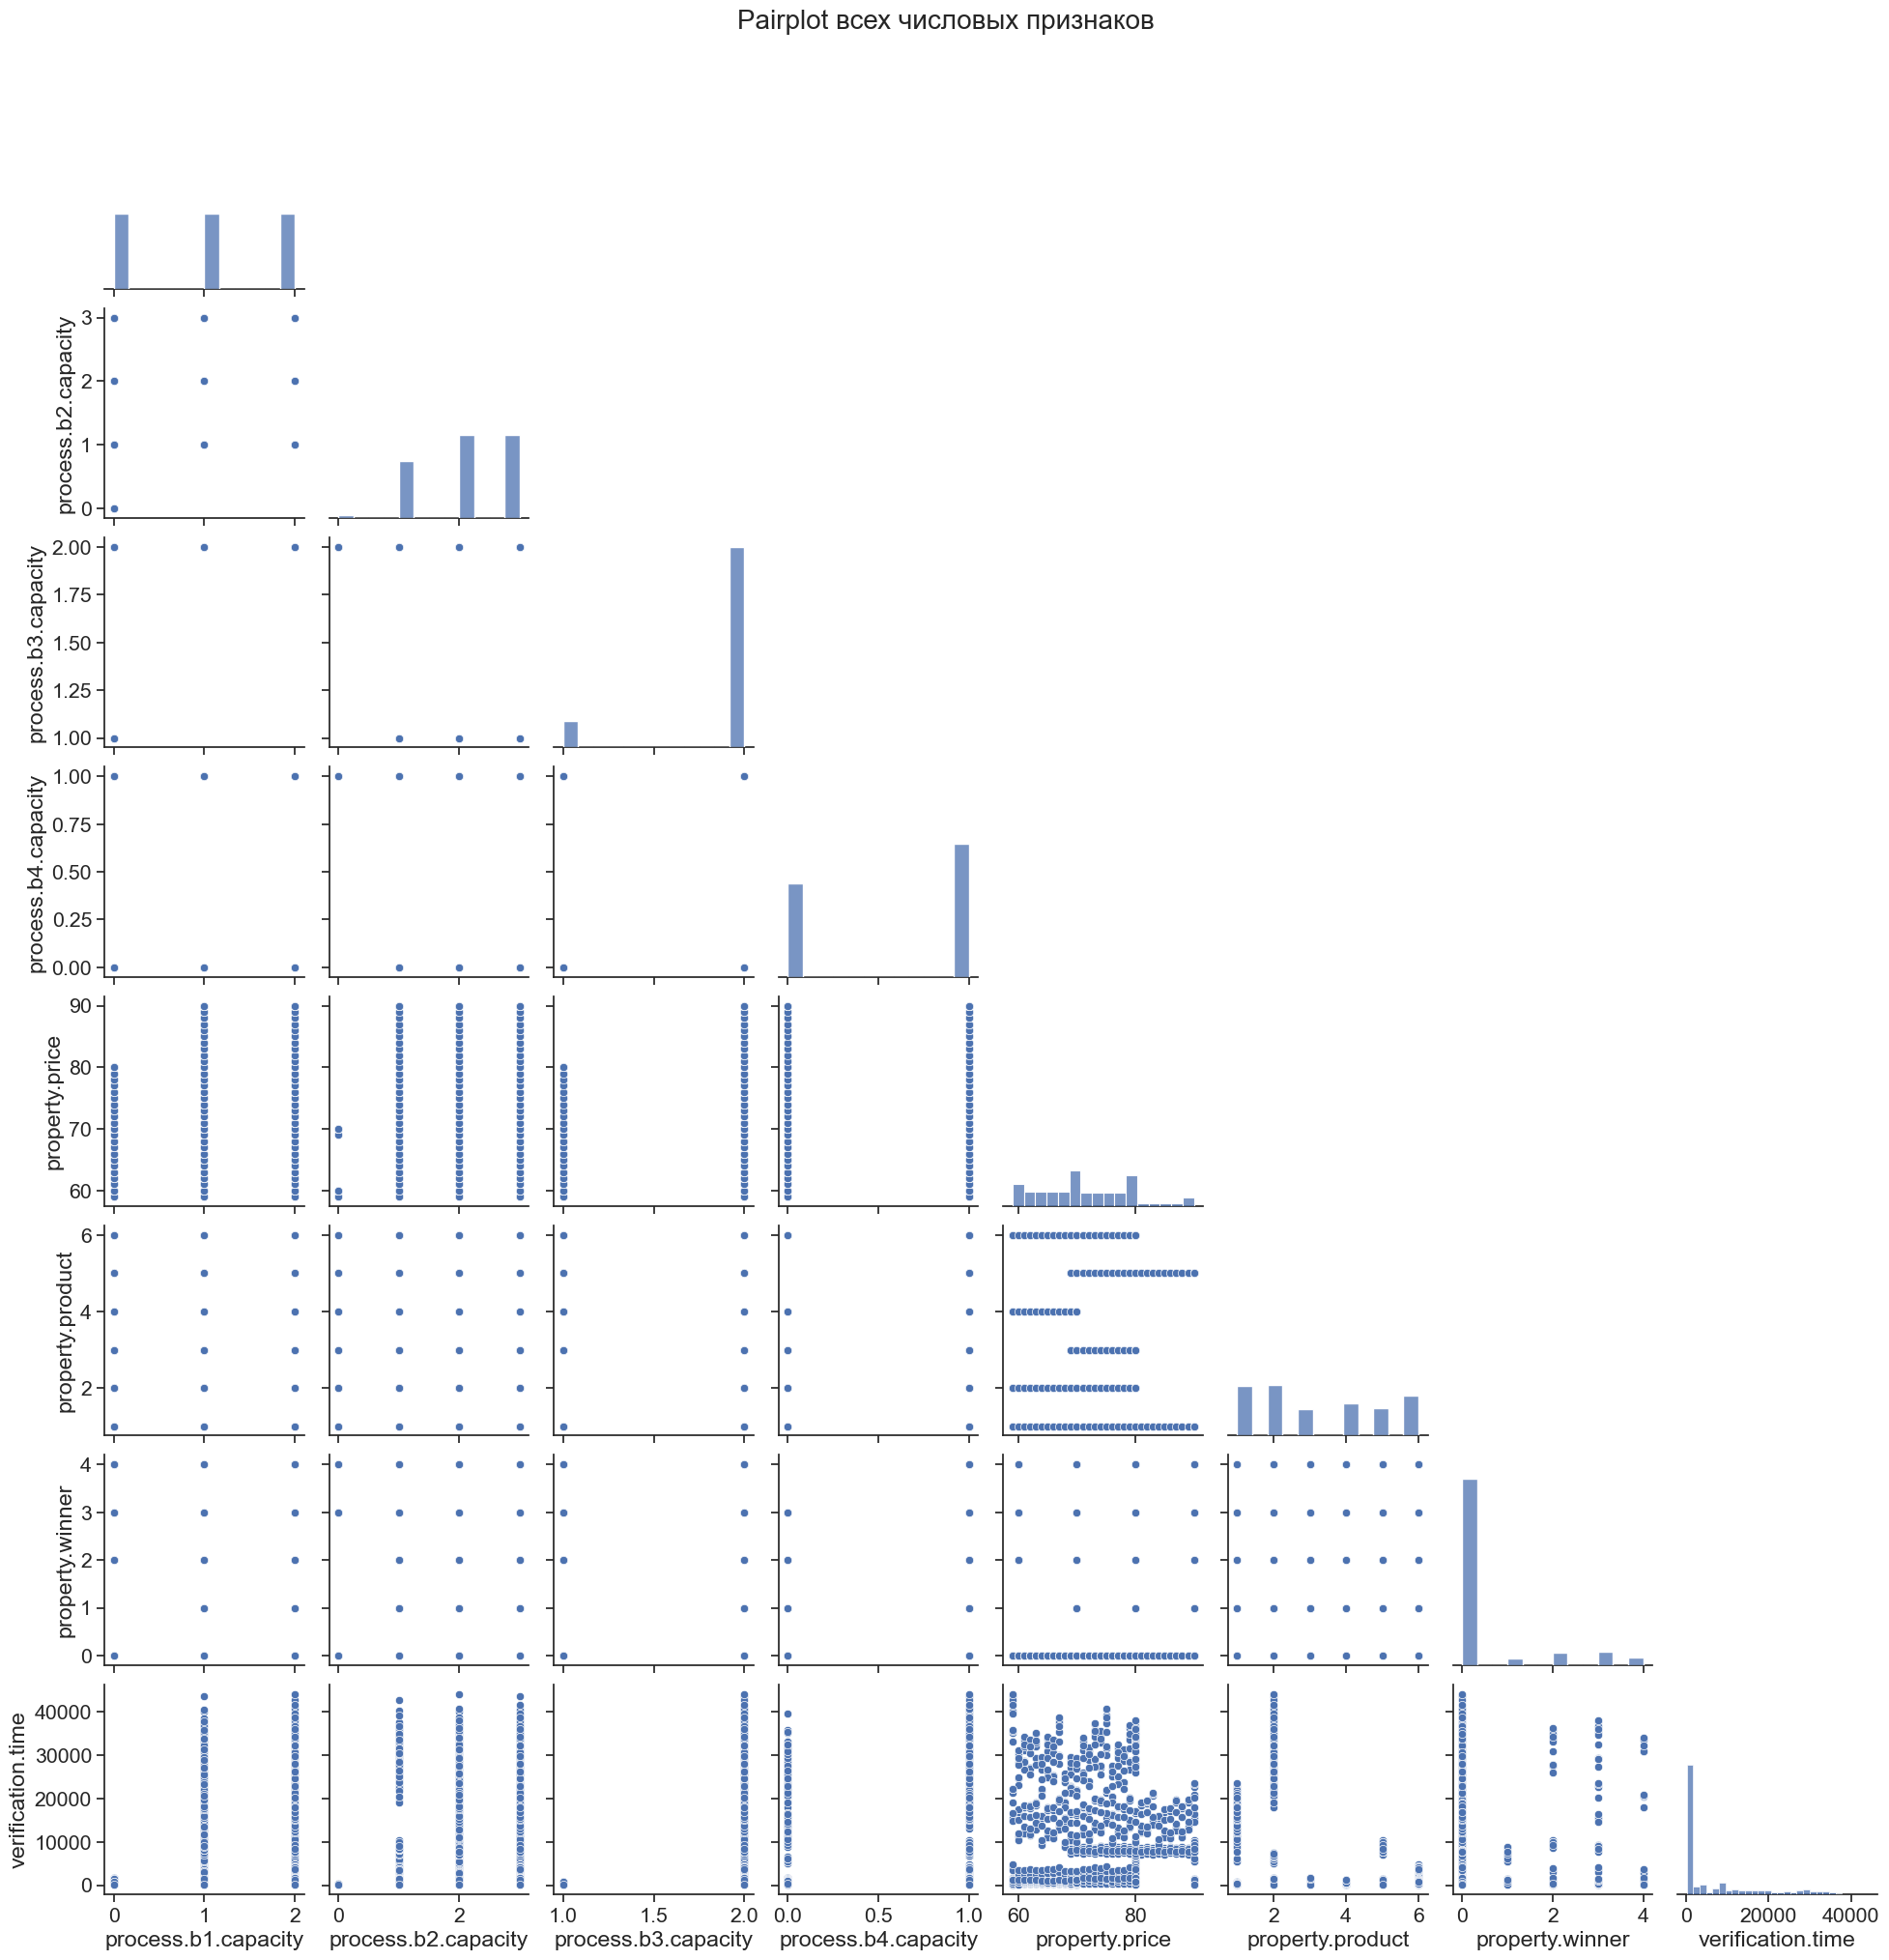

In [6]:
# Выбираем все числовые признаки
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Строим Pairplot
sns.set(style="ticks", font_scale=1.4)
pair = sns.pairplot(df[numeric_cols], corner=True)
pair.fig.suptitle('Pairplot всех числовых признаков', y=1.02, fontsize=20)

plt.show()

In [8]:
# Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Признаки и целевая переменная
X = df.drop(columns=['verification.result', 'verification.time'])
y = np.log1p(df['verification.time'])  # логарифмирование target-а

# 2. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Стандартизация признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Предсказания (в лог-пространстве)
y_pred_log = model.predict(X_test_scaled)

# 6. Обратное преобразование (из log обратно к реальным значениям)
y_test_original = np.expm1(y_test)  # exp(x) - 1
y_pred_original = np.expm1(y_pred_log)

# 7. Оценка качества
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100
r2 = r2_score(y_test_original, y_pred_original)

# 8. Вывод результатов
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'R^2 Score: {r2:.4f}')

Mean Absolute Error (MAE): 5134.4700
Root Mean Squared Error (RMSE): 9229.7945
Mean Absolute Percentage Error (MAPE): 239.99%
R^2 Score: 0.1831
